<a href="https://colab.research.google.com/github/saradindu-chaudhuri/Immunotherapy_Survival_ML/blob/main/Cohort_Generation_%26_Baseline_Cox_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lifelines

--- IMMUNE COHORT SUMMARY ---
        time  event        Age  Sex       NLR       CRP  PD1_Expression
0  11.896446      1  66.967142    1  2.763342  1.997156       16.002494
1  30.461344      1  60.617357    1  3.232827  2.501853        2.335210
2  36.000000      0  68.476885    0  5.491791  9.209618       75.621361
3   8.137262      1  77.230299    1  1.996773  3.021832       45.852301
4  19.232167      1  59.658466    1  3.612271  2.391339       28.924477

--- COX PROPORTIONAL HAZARDS RESULTS ---


<lifelines.CoxPHFitter: fitted with 500 total observations, 239 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 261
   partial log-likelihood = -1459.15
         time fit was run = 2026-09-07 04:20:19 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Age             0.04      1.04      0.01            0.03            0.06                1.03                1.06
Sex             0.24      1.27      0.13           -0.01            0.49                0.99                1.63
NLR             0.14      1.16      0.03            0.08            0.21                1.09                1.23
CRP             0.10      1.11      0.02            0.07            0.13                1.07                1.14
PD1_Expression -0.02      0.98      0.00           -0.03           -0.02                0.97                0.98

                cmp to     z      p  -log2(p)
covariate                                    
Age               0.00  6.46 <0.005     33.13
Sex               0.00  1.91   0.06      4.14
NLR               0.00  4.64 <0.005     18.14
CRP               0.00  6.21 <0.005     30.77
PD1_Expression    0.00 -9.23 <0.005     64.98
---
Concordance = 0.71
Partial AIC = 2928.31
log-likelihood ratio test = 157.29 on 5 df
-log2(p) of ll-ratio test = 104.40

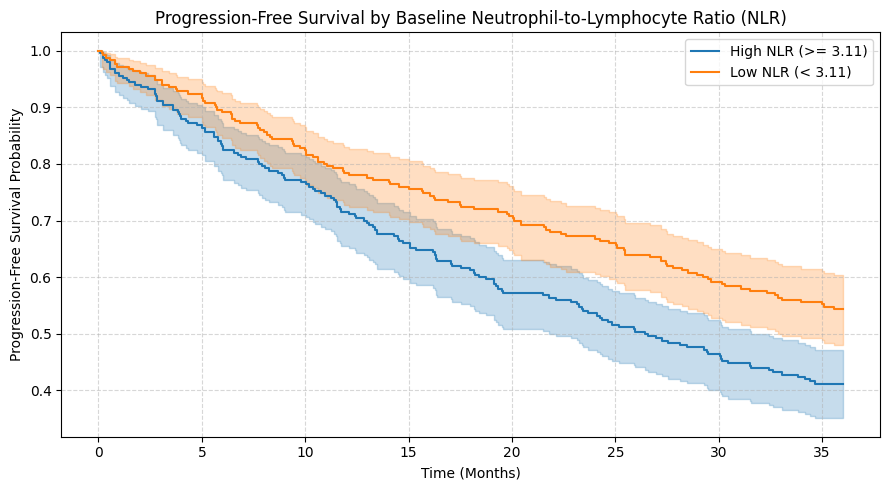

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

# 1. Seed for reproducibility
np.random.seed(42)
n_samples = 500

# 2. Generate Synthetic Immune & Clinical Data
age = np.random.normal(62, 10, n_samples).clip(35, 85)
sex = np.random.binomial(1, 0.5, n_samples)
nlr = np.random.lognormal(mean=1.1, sigma=0.5, size=n_samples) # Neutrophil-to-Lymphocyte Ratio
crp = np.random.lognormal(mean=1.5, sigma=0.6, size=n_samples) # C-Reactive Protein (mg/L)
pd1_expression = np.random.uniform(0, 100, n_samples)    # PD-L1 Expression %

# 3. Simulate Survival Time based on Immune Risk Score
# Higher NLR and higher CRP increase hazard; high PD-L1 decreases hazard
baseline_hazard = 0.02
risk_score = 0.03 * (age - 60) + 0.4 * np.log(nlr) + 0.3 * np.log(crp) - 0.02 * pd1_expression
survival_time = np.random.exponential(scale=1.0 / (baseline_hazard * np.exp(risk_score)))

# Censor data at 36 months max follow-up
max_followup = 36.0
observed_time = np.minimum(survival_time, max_followup)
event_occurred = (survival_time <= max_followup).astype(int)

# 4. Construct Dataframe
df_immune = pd.DataFrame({
    'time': observed_time,
    'event': event_occurred,
    'Age': age,
    'Sex': sex,
    'NLR': nlr,
    'CRP': crp,
    'PD1_Expression': pd1_expression
})

print("--- IMMUNE COHORT SUMMARY ---")
print(df_immune.head())

# 5. Fit Cox Proportional Hazards Model
cph = CoxPHFitter()
cph.fit(df_immune, duration_col='time', event_col='event')

print("\n--- COX PROPORTIONAL HAZARDS RESULTS ---")
cph.print_summary()

# 6. Plot Survival Curves by High vs Low NLR
median_nlr = df_immune['NLR'].median()
high_nlr = df_immune[df_immune['NLR'] >= median_nlr]
low_nlr = df_immune[df_immune['NLR'] < median_nlr]

kmf = KaplanMeierFitter()
plt.figure(figsize=(9, 5))

kmf.fit(high_nlr['time'], high_nlr['event'], label=f'High NLR (>= {median_nlr:.2f})')
kmf.plot_survival_function(ci_show=True)

kmf.fit(low_nlr['time'], low_nlr['event'], label=f'Low NLR (< {median_nlr:.2f})')
kmf.plot_survival_function(ci_show=True)

plt.title('Progression-Free Survival by Baseline Neutrophil-to-Lymphocyte Ratio (NLR)')
plt.xlabel('Time (Months)')
plt.ylabel('Progression-Free Survival Probability')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
# Install scikit-survival if not already installed
!pip uninstall -y scikit-learn scikit-survival
!pip install scikit-learn==1.3.2
!pip install scikit-survival

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
# from sksurv.util import Service # Removed this line as 'Service' is no longer available in sksurv.util

# 1. Format Data for scikit-survival
# Survival target must be a structured array of (event_boolean, time)
y_structured = np.array(
    list(zip(df_immune['event'].astype(bool), df_immune['time'])),
    dtype=[('Status', '?'), ('Survival_in_months', '<f8')]
)

X = df_immune[['Age', 'Sex', 'NLR', 'CRP', 'PD1_Expression']]

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_structured, test_size=0.25, random_state=42
)

# 3. Fit Random Survival Forest
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rsf.fit(X_train, y_train)

# 4. Evaluate Concordance Index on Unseen Test Data
c_index_train = rsf.score(X_train, y_train)
c_index_test = rsf.score(X_test, y_test)

print("--- RANDOM SURVIVAL FOREST RESULTS ---")
print(f"Train C-Index: {c_index_train:.3f}")
print(f"Test C-Index:  {c_index_test:.3f}")

Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
Found existing installation: scikit-survival 0.28.0
Uninstalling scikit-survival-0.28.0:
  Successfully uninstalled scikit-survival-0.28.0
  Using cached scikit-learn-1.3.2.tar.gz (7.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  Using cached scikit_survival-0.28.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.

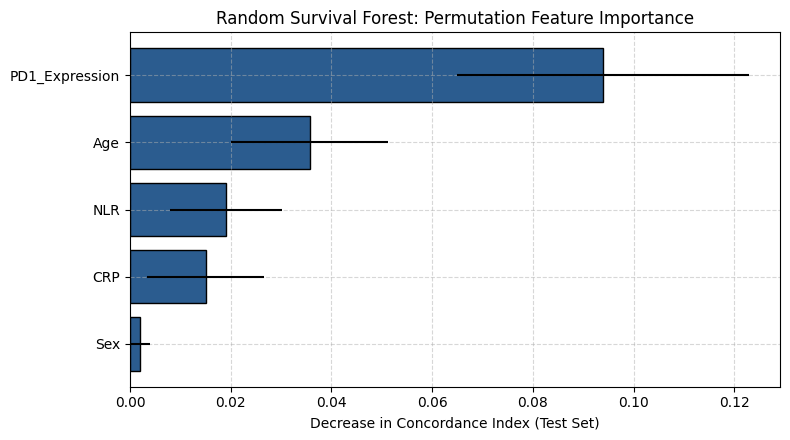

--- PERMUTATION FEATURE IMPORTANCE ---
       Feature  Importance_Mean  Importance_Std
PD1_Expression         0.093945        0.028987
           Age         0.035656        0.015497
           NLR         0.019079        0.011069
           CRP         0.015042        0.011620
           Sex         0.002018        0.001916


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1. Calculate Permutation Feature Importance using scikit-learn
result = permutation_importance(
    rsf, X_test, y_test, n_repeats=10, random_state=42
)

# 2. Organize into a DataFrame
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=True)

# 3. Plot Feature Importances
plt.figure(figsize=(8, 4.5))
plt.barh(importance_df['Feature'], importance_df['Importance_Mean'],
         xerr=importance_df['Importance_Std'], color='#2b5c8f', edgecolor='black')
plt.xlabel('Decrease in Concordance Index (Test Set)')
plt.title('Random Survival Forest: Permutation Feature Importance')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- PERMUTATION FEATURE IMPORTANCE ---")
print(importance_df.sort_values(by='Importance_Mean', ascending=False).to_string(index=False))